### Case Study

I performed **predictive and descriptive analyses** to understand customer behavior, store performance, and sales drivers. The analyses included:

* **Linear Regression:** Identified key factors affecting total sales.
* **Decision Tree Regression:** Explored non-linear patterns and feature interactions.
* **K-Means Clustering:** Classified customers based on purchase behavior.

 Importing necessary libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


Loading the datasets.

In [ ]:
# Load Excel file
file_path = "case-study-data.xlsx"

# View sheet names
xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

['Fact_table', 'Trans_dim', 'Item_dim', 'Customer_dim', 'Time_dim', 'Store_dim']


In [ ]:
fact = pd.read_excel(file_path, sheet_name="Fact_table")
item = pd.read_excel(file_path, sheet_name="Item_dim")
customer = pd.read_excel(file_path, sheet_name="Customer_dim")
store = pd.read_excel(file_path, sheet_name="Store_dim")

Data Cleaning

In [ ]:
# Make column names simple (all lowercase)
fact.columns = fact.columns.str.lower()
item.columns = item.columns.str.lower()

# Clean 'unit' column (if present)
if 'unit' in fact.columns:
    fact['unit'] = fact['unit'].astype(str).str.lower().str.strip()
if 'unit' in item.columns:
    item['unit'] = item['unit'].astype(str).str.lower().str.strip()

# Check missing values
fact.isnull().sum()


,0
payment_key,0
customer_key,0
time_key,0
item_key,0
store_key,0
quantity_sold,0
unit,0
unit_price,0
total_price,0


Data Manipulation

In [ ]:
# Merge the data so we can analyze everything together
data = fact.merge(item, on='item_key', how='left')
data = data.merge(customer, on='customer_key', how='left')
data = data.merge(store, on='store_key', how='left')

print("Merged dataset shape:", data.shape)
display(data.head())

Merged dataset shape: (100000, 30)


,payment_key,customer_key,time_key,item_key,store_key,quantity_sold,unit_x,unit_price_x,total_price,item_name,...,street,upazila_x,district_x,division_x,store_size,location,city,upazila_y,district_y,division_y
0,P025,C005440,T01562,I00264,S0035,1,ct,15.0,15.0,Tylenol Extra Strength 2 pill packets,...,"Rurual Development Officer, BRDB Gournadi",Gournadi,Barishal,Barishal,large,"Boira, Dhaka road",Khulna,Boira,Khulna,Khulna
1,P002,C002862,T02119,I00264,S0008,7,ct,15.0,105.0,Tylenol Extra Strength 2 pill packets,...,Bishwanath,Bishwanath,Sylhet,Sylhet,medium,9 A road,Sunamganj,Jamalganj,Sunamganj,Sylhet
2,P001,C000360,T04322,I00091,S0024,4,bottles,7.5,30.0,Nestle Purelife 16oz,...,"House-9, Naveana Garden. Kallyanpur",Mirpur-1,Dhaka,Dhaka,large,"H-607,R-10 Baitul Aman Housing Society, Rajshahi",Rajshahi,Rajshahi,Rajshahi,Rajshahi
3,P013,C001636,T02225,I00174,S0037,11,oz,18.0,198.0,Hershey Kisses,...,"House-08, Road-10/A, Sec-09",Uttara,Dhaka,Dhaka,small,Hill town,Rangamati,Baghaichari,Rangamati,Chittagong
4,P039,C000641,T04425,I00241,S0009,6,ct,12.0,72.0,Peppermints Hard Candy,...,"Rurual Development Officer, BRDB Gournadi",Gournadi,Barishal,Barishal,small,Infront of Mohonpur jame mosjid,Sunamganj,Tahirpur,Sunamganj,Sylhet


#Descriptive Analysis

In [ ]:
# Basic information
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   payment_key     100000 non-null  object 
 1   customer_key    100000 non-null  object 
 2   time_key        100000 non-null  object 
 3   item_key        100000 non-null  object 
 4   store_key       100000 non-null  object 
 5   quantity_sold   100000 non-null  int64  
 6   unit_x          100000 non-null  object 
 7   unit_price_x    100000 non-null  float64
 8   total_price     100000 non-null  float64
 9   item_name       100000 non-null  object 
 10  item_type       100000 non-null  object 
 11  unit_price_y    100000 non-null  float64
 12  man_country     100000 non-null  object 
 13  supplier        100000 non-null  object 
 14  stock_quantity  100000 non-null  int64  
 15  unit_y          100000 non-null  object 
 16  name            99682 non-null   object 
 17  contact_no 

##Analysis By Sales

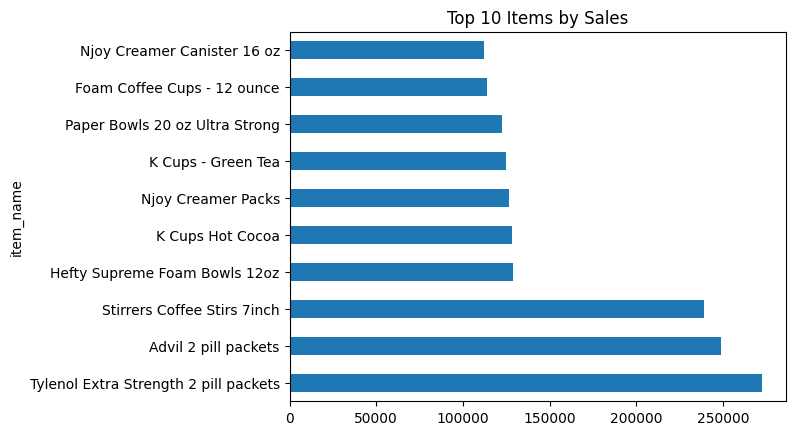

In [ ]:
# Top 10 items by sales
top_items = data.groupby('item_name')['total_price'].sum().sort_values(ascending=False).head(10)
top_items.plot(kind='barh', title='Top 10 Items by Sales')
plt.show()



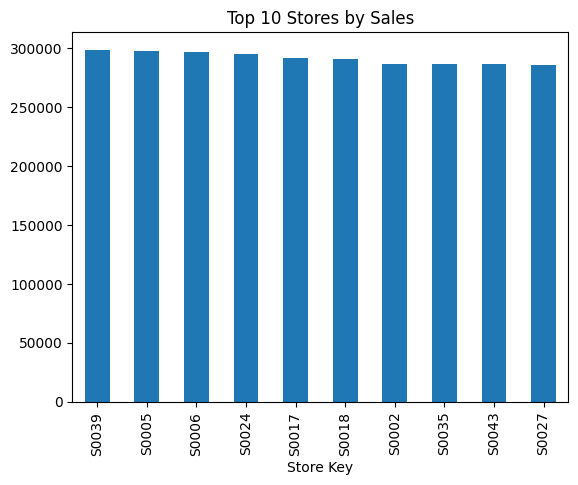

In [ ]:
# Sales by store
sales_by_store = data.groupby('store_key')['total_price'].sum().sort_values(ascending=False).head(10)
sales_by_store.index.name = 'Store Key'
sales_by_store.plot(kind='bar', title='Top 10 Stores by Sales')
plt.show()

##Analysis by Payment

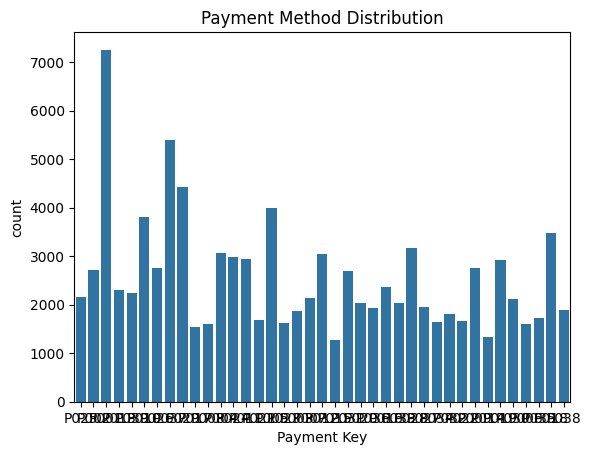

In [ ]:
sns.countplot(x='payment_key', data=data)
plt.title("Payment Method Distribution")
plt.xlabel("Payment Key")
plt.show()

#Predictive Analysis

###Regression analysis of tolal price

In [ ]:
# Select useful columns for prediction
ml_data = data[['quantity_sold', 'unit_price_x', 'total_price', 'payment_key', 'store_key']].copy()

# Convert categorical columns to numbers
ml_data = pd.get_dummies(ml_data, columns=['payment_key', 'store_key'], drop_first=True)

# Separate features and target
X = ml_data.drop('total_price', axis=1)
y = ml_data['total_price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

# Create the model
model = LinearRegression()

# Train (fit) the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

Model Performance:
Mean Absolute Error: 12.97
R² Score: 0.9


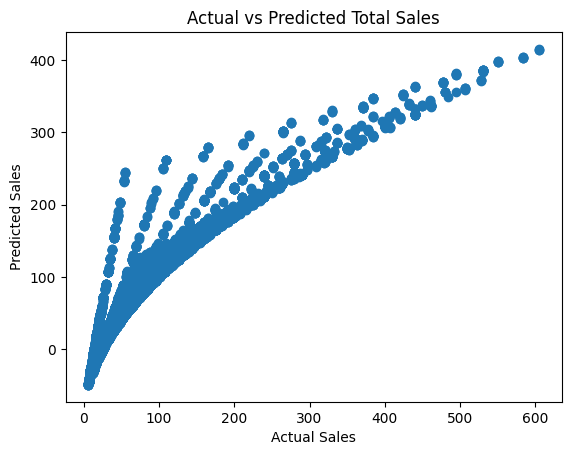

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Total Sales")
plt.show()


In [ ]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coeff_df)


             Feature  Coefficient
0      quantity_sold    16.985144
1       unit_price_x     6.000546
61   store_key_S0023     1.452316
77   store_key_S0039     1.335402
71   store_key_S0033     1.305305
..               ...          ...
2   payment_key_P002    -0.793991
36  payment_key_P036    -0.847666
8   payment_key_P008    -0.897755
17  payment_key_P017    -0.905949
34  payment_key_P034    -0.955944

[83 rows x 2 columns]


**Regression Analysis:**

* **Quantity sold** and **unit price** are the strongest drivers of total sales.
* Certain **stores** and **digital payment types** are associated with higher sales.

## Customer Classification by total price and quantity sold


Average values per cluster:
         total_price  quantity_sold
Cluster                            
0        1152.663173      68.129908
1        1702.609392      97.016009
2         695.461755      42.815047


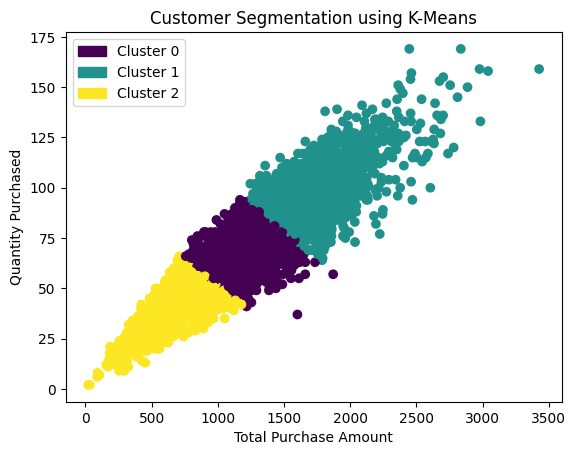

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # Import mpatches for custom legend

# Prepare customer-level data
cust_data = data.groupby('customer_key').agg({
    'total_price': 'sum',
    'quantity_sold': 'sum'
}).reset_index()

# Standardize data so that large numbers don't dominate
scaler = StandardScaler()
cust_scaled = scaler.fit_transform(cust_data[['total_price', 'quantity_sold']])

# Fit K-Means (try 3 groups)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cust_data['Cluster'] = kmeans.fit_predict(cust_scaled)

# Check average sales and quantity per cluster
print("\nAverage values per cluster:")
print(cust_data.groupby('Cluster')[['total_price', 'quantity_sold']].mean())

# Visualize clusters
plt.scatter(cust_data['total_price'], cust_data['quantity_sold'], c=cust_data['Cluster'], cmap='viridis')
plt.xlabel('Total Purchase Amount')
plt.ylabel('Quantity Purchased')
plt.title('Customer Segmentation using K-Means')
# Create custom legend
colors = ['#440154', '#21918c', '#fde725']  # colors from viridis colormap
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(3)]
plt.legend(handles=patches)
plt.show()

**K-Means Clustering:**

* Customers naturally fall into **three clusters** based on total purchases and quantity bought:

  1. **High-value customers** – frequent purchases, high spend
  2. **Medium-value customers** – moderate purchases and spend
  3. **Low-value customers** – infrequent or low spend

#Decision Tree

Building a Decision Tree model to predict how much a customer will spend (total_price) based on:

Quantity bought

Unit price

Payment type

Store

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
# Select relevant columns
# ml_data = data[['quantity_sold', 'unit_price', 'total_price', 'transaction_type', 'store_id']].copy()
ml_data = data[['quantity_sold', 'unit_price_x', 'total_price', 'payment_key', 'store_key']].copy()

# Convert categorical variables
# ml_data = pd.get_dummies(ml_data, columns=['transaction_type', 'store_id'], drop_first=True)
ml_data = pd.get_dummies(ml_data, columns=['payment_key', 'store_key'], drop_first=True)


# Features and target
X = ml_data.drop('total_price', axis=1)
y = ml_data['total_price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build decision tree
tree = DecisionTreeRegressor(max_depth=5, random_state=50)
tree.fit(X_train, y_train)

# Predictions
y_pred_tree = tree.predict(X_test)

# Evaluate performance
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(" Decision Tree Performance:")
print("Mean Absolute Error:", round(mae_tree, 2))
print("R² Score:", round(r2_tree, 2))

 Decision Tree Performance:
Mean Absolute Error: 11.38
R² Score: 0.96


## Seeing how the decision tree finds which features affect sales the most

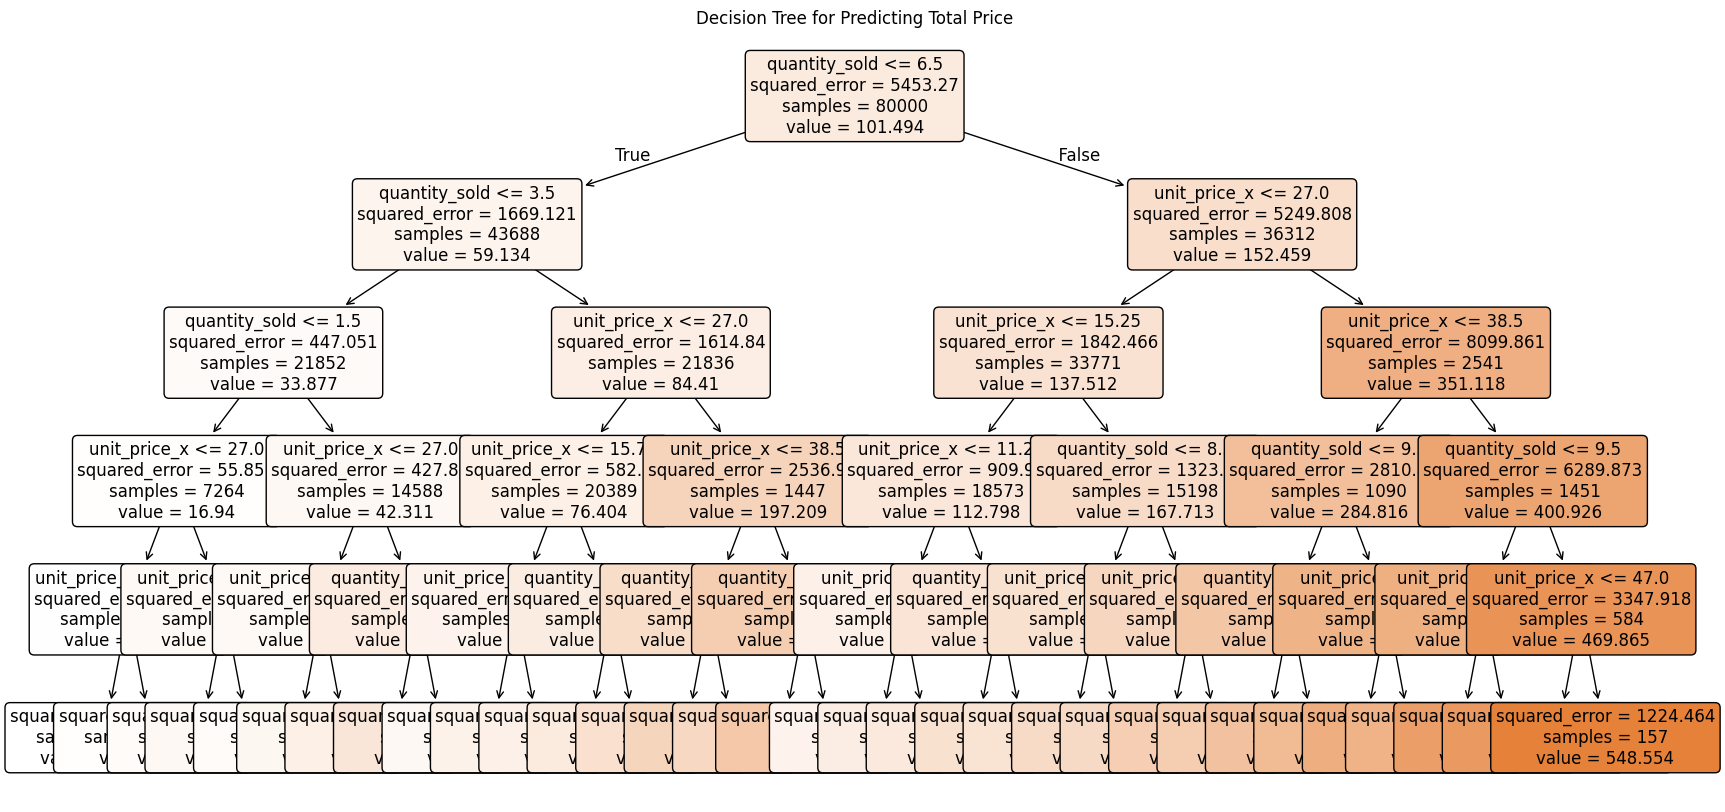

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the tree
plt.figure(figsize=(20,10))  # Make the plot bigger for readability
plot_tree(
    tree,                      # trained tree
    feature_names=X.columns,   # Feature names for labels
    filled=True,               # Color nodes by value
    rounded=True,              # Rounded boxes
    fontsize=12                # Font size
)
plt.title("Decision Tree for Predicting Total Price")
plt.show()


##Using Decision Tree Feature Importance

In [ ]:
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feat_importance)


             Feature  Importance
0      quantity_sold    0.539545
1       unit_price_x    0.460455
2   payment_key_P002    0.000000
3   payment_key_P003    0.000000
4   payment_key_P004    0.000000
..               ...         ...
78   store_key_S0040    0.000000
79   store_key_S0041    0.000000
80   store_key_S0042    0.000000
81   store_key_S0043    0.000000
82   store_key_S0044    0.000000

[83 rows x 2 columns]


**Decision Tree Analysis:**

* Customers purchasing **more than 5 units** tend to generate significantly higher total sales.
* Top-performing stores and payment methods consistently influence higher sales.

Comparison of the Actual Vs Predicted Sales

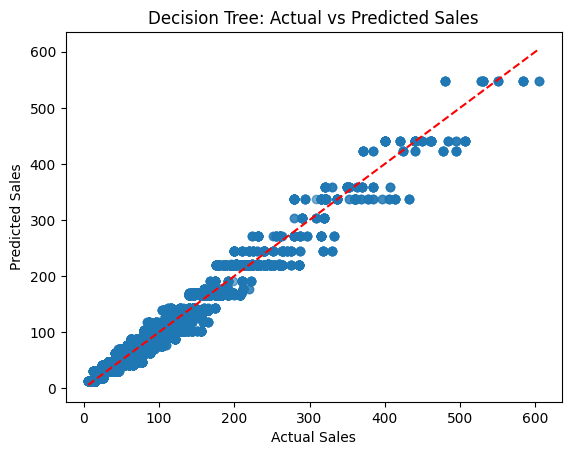

In [ ]:
plt.scatter(y_test, y_pred_tree, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Decision Tree: Actual vs Predicted Sales")
plt.show()


# Time Series Analysis

Using time series to understand when and how much sales will happen.

In [ ]:
time_dim = pd.read_excel(file_path, sheet_name="Time_dim")
print(time_dim.columns)


Index(['time_key', 'date', 'hour', 'day', 'week', 'month', 'quarter', 'year'], dtype='object')


In [ ]:
# Merge to get date info
fact_time = fact.merge(time_dim, on='time_key', how='left')

# Check result
fact_time.head()

,payment_key,customer_key,time_key,item_key,store_key,quantity_sold,unit,unit_price,total_price,date,hour,day,week,month,quarter,year
0,P025,C005440,T01562,I00264,S0035,1,ct,15.0,15.0,11-07-2016 13:18,13,11,2nd Week,7,Q3,2016
1,P002,C002862,T02119,I00264,S0008,7,ct,15.0,105.0,19-02-2016 05:10,5,19,3rd Week,2,Q1,2016
2,P001,C000360,T04322,I00091,S0024,4,bottles,7.5,30.0,13-01-2020 17:25,17,13,2nd Week,1,Q1,2020
3,P013,C001636,T02225,I00174,S0037,11,oz,18.0,198.0,15-06-2019 00:58,0,15,3rd Week,6,Q2,2019
4,P039,C000641,T04425,I00241,S0009,6,ct,12.0,72.0,01-01-2019 07:30,7,1,1st Week,1,Q1,2019


In [ ]:
# Convert date column to datetime type
fact_time['date'] = pd.to_datetime(fact_time['date'], format='%d-%m-%Y %H:%M', errors='coerce')

# Group sales by month
monthly_sales = fact_time.groupby(pd.Grouper(key='date', freq='M'))['total_price'].sum().reset_index()

monthly_sales.head()

/tmp/ipython-input-3115135248.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = fact_time.groupby(pd.Grouper(key='date', freq='M'))['total_price'].sum().reset_index()


,date,total_price
0,2014-01-31,38514.50
1,2014-02-28,121872.00
2,2014-03-31,127090.25
3,2014-04-30,117236.00
4,2014-05-31,138108.50


In [ ]:
# Convert date column to datetime type
fact_time['date'] = pd.to_datetime(fact_time['date'])

# Group sales by month
monthly_sales = fact_time.groupby(pd.Grouper(key='date', freq='M'))['total_price'].sum().reset_index()

monthly_sales.head()


/tmp/ipython-input-1777069909.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = fact_time.groupby(pd.Grouper(key='date', freq='M'))['total_price'].sum().reset_index()


,date,total_price
0,2014-01-31,38514.50
1,2014-02-28,121872.00
2,2014-03-31,127090.25
3,2014-04-30,117236.00
4,2014-05-31,138108.50


Visualizing total sales in different months

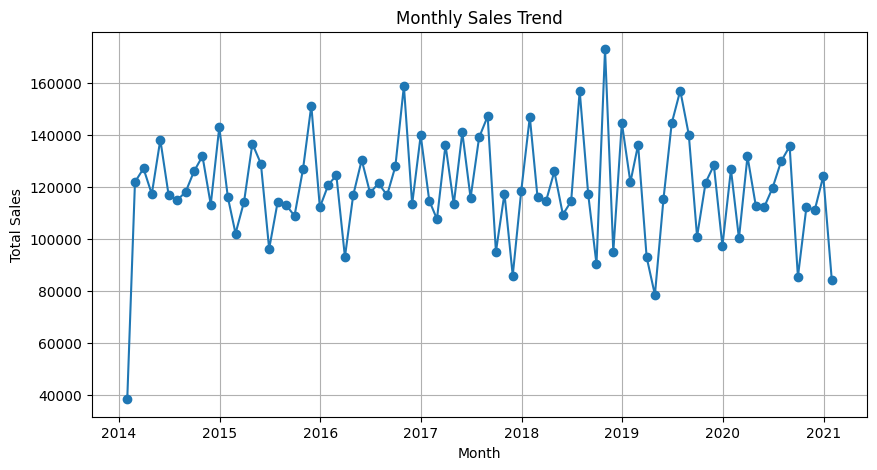

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['date'], monthly_sales['total_price'], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


##Sales forecast of next six months

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-2061176023.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(ts.index[-1], periods=6, freq='M')


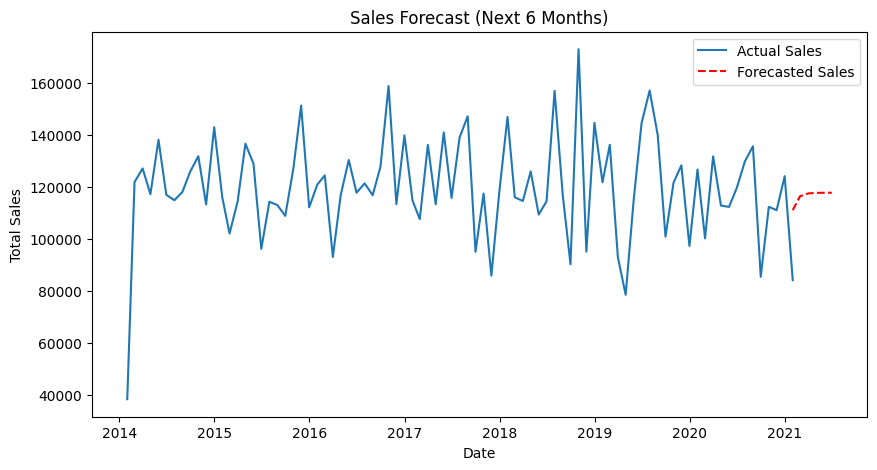

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Set date as index
ts = monthly_sales.set_index('date')['total_price']

# Fit ARIMA model
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

# Forecast for next 6 months
forecast = model_fit.forecast(steps=6)

# Create forecast dataframe
future_dates = pd.date_range(ts.index[-1], periods=6, freq='M')
forecast_df = pd.DataFrame({'Date': future_dates, 'Forecast': forecast})

# Plot actual vs forecast
plt.figure(figsize=(10,5))
plt.plot(ts, label='Actual Sales')
plt.plot(forecast_df['Date'], forecast_df['Forecast'], label='Forecasted Sales', color='red', linestyle='--')
plt.title("Sales Forecast (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.show()


# Prescriptive Analysis









###**Prescriptive Recommendations**

**A. Customer Actions**

1. High-value customers: Give loyalty rewards, special discounts, or personalized offers to keep them coming back.

2. Medium-value customers: Suggest bundle deals or add-on products to increase their spending.

3. Low-value customers: Send introductory offers or small promotions to get them more involved.

**B. Store Actions**

1. Stores with low sales: Make sure popular products are in stock, improve inventory, or run local promotions.

2. Stores with high sales: Keep doing what works and consider expanding successful strategies.

**C. Pricing & Product Actions**

1. Change unit prices carefully to improve sales based on what the analysis shows.

2. Offer volume discounts or bundles to encourage customers to buy more.

**D. Payment & Transaction Actions**

1. Encourage digital payments if customers paying this way tend to spend more.

2. Offer online promotions or small incentives for card payments to boost sales.

**E. Planning & Scheduling (from Sales Forecasts)**

1. Plan inventory and staff according to predicted busy periods.

2. Schedule marketing campaigns during high-demand or seasonal times.

Further we can consider doing:

->Run targeted marketing campaigns based on customer clusters.

->Adjust pricing and discounts based on important factors from regression and decision tree results.

->Track sales after these actions and adjust strategies as needed to improve results.


